In [ ]:
import webbrowser as wb
wb.open("https://www.scaler.com/academy/mentee-dashboard/class/109664/project/problems/19040?navref=cl_tt_crd_sl")
path=!cd
import os
os.startfile(path[0]+'\\Other')

In [ ]:
path=!cd
import os
os.startfile(path[0]+'\\Other')

**Understand Business Problem**

OLA is an online cab providing company which is facing drivers churing the company on daily basis, due to which they are
suffering losses as hiring new drivers is more expensive than trying to retain previous drivers, OLA needs help in determining
which parameters are effective in deciding weather a driver will churn or not as to stop the net loss they are making.

Recruiting and retaining drivers is seen by industry watchers as a tough battle for Ola. Churn among drivers is high and it’s very easy for drivers to stop working for the service on the fly or jump to Uber depending on the rates.

As the companies get bigger, the high churn could become a bigger problem. To find new drivers, Ola is casting a wide net, including people who don’t have cars for jobs. But this acquisition is really costly. Losing drivers frequently impacts the morale of the organization and acquiring new drivers is more expensive than retaining existing ones.

You are working as a data scientist with the Analytics Department of Ola, focused on driver team attrition. You are provided with the monthly information for a segment of drivers for 2019 and 2020 and tasked to predict whether a driver will be leaving the company or not based on their attributes like

Demographics (city, age, gender etc.)
Tenure information (joining date, Last Date)
Historical data regarding the performance of the driver (Quarterly rating, Monthly business acquired, grade, Income)

### Exploratory Data Anlaysis

In [121]:
import pandas as pd
df = pd.read_csv('Data_Ola.csv')
df

,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19099,19099,08/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,740280,3
19100,19100,09/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,448370,3
19101,19101,10/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,0,2
19102,19102,11/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,200420,2


In [122]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')
df.columns

Index(['unnamed:_0', 'mmm-yy', 'driver_id', 'age', 'gender', 'city',
       'education_level', 'income', 'dateofjoining', 'lastworkingdate',
       'joining_designation', 'grade', 'total_business_value',
       'quarterly_rating'],
      dtype='object')

In [123]:
df.rename(columns={'mmm-yy':'date'}, inplace=True)

In [124]:
df.drop(columns=['unnamed:_0'], inplace=True)

In [125]:
df.describe()

,driver_id,age,gender,education_level,income,joining_designation,grade,total_business_value,quarterly_rating
count,19104.000000,19043.000000,19052.000000,19104.000000,19104.000000,19104.000000,19104.000000,1.910400e+04,19104.000000
mean,1415.591133,34.668435,0.418749,1.021671,65652.025126,1.690536,2.252670,5.716621e+05,2.008899
std,810.705321,6.257912,0.493367,0.800167,30914.515344,0.836984,1.026512,1.128312e+06,1.009832
min,1.000000,21.000000,0.000000,0.000000,10747.000000,1.000000,1.000000,-6.000000e+06,1.000000
25%,710.000000,30.000000,0.000000,0.000000,42383.000000,1.000000,1.000000,0.000000e+00,1.000000
50%,1417.000000,34.000000,0.000000,1.000000,60087.000000,1.000000,2.000000,2.500000e+05,2.000000
75%,2137.000000,39.000000,1.000000,2.000000,83969.000000,2.000000,3.000000,6.997000e+05,3.000000
max,2788.000000,58.000000,1.000000,2.000000,188418.000000,5.000000,5.000000,3.374772e+07,4.000000


In [126]:
df=df.convert_dtypes()
df.info()
# Misssing val columns
# Check Dtype change if needed

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   date                  19104 non-null  string
 1   driver_id             19104 non-null  Int64 
 2   age                   19043 non-null  Int64 
 3   gender                19052 non-null  Int64 
 4   city                  19104 non-null  string
 5   education_level       19104 non-null  Int64 
 6   income                19104 non-null  Int64 
 7   dateofjoining         19104 non-null  string
 8   lastworkingdate       1616 non-null   string
 9   joining_designation   19104 non-null  Int64 
 10  grade                 19104 non-null  Int64 
 11  total_business_value  19104 non-null  Int64 
 12  quarterly_rating      19104 non-null  Int64 
dtypes: Int64(9), string(4)
memory usage: 2.1 MB


In [128]:
df['date'] = pd.to_datetime(df['date'])
df['dateofjoining'] = pd.to_datetime(df['dateofjoining'])
df['dastworkingdate'] = pd.to_datetime(df['lastworkingdate'])

In [130]:
df.nunique()
# Identity Records Columns

date                       24
driver_id                2381
age                        36
gender                      2
city                       29
education_level             3
income                   2383
dateofjoining             869
lastworkingdate           493
joining_designation         5
grade                       5
total_business_value    10181
quarterly_rating            4
dastworkingdate           493
dtype: int64

df.drop('unnamed:_0', axis = 1, inplace=True)

In [131]:
df.groupby('date')['driver_id'].nunique().sort_index(ascending=True)

date
2019-01-01    1022
2019-02-01     944
2019-03-01     870
2019-04-01     794
2019-05-01     764
2019-06-01     726
2019-07-01     757
2019-08-01     754
2019-09-01     762
2019-10-01     739
2019-11-01     781
2019-12-01     795
2020-01-01     782
2020-02-01     761
2020-03-01     719
2020-04-01     729
2020-05-01     766
2020-06-01     770
2020-07-01     806
2020-08-01     812
2020-09-01     809
2020-10-01     818
2020-11-01     805
2020-12-01     819
Name: driver_id, dtype: int64

**Understand the data**
- Granularity
  Data has records of 24 days of each month in 2 year containg drivers montly earning.
- Data also contails details of driver.
    
    Fixed info = Driver ID, Gender, City, Education, joiningdesignation, joiningdate, Lastdate
    
    Variabel info (based on date) = Income, Grade, Rating (deciding factors of target)

In [132]:
df['gender'].value_counts(normalize=True,dropna=False)
# NaN can be filled with KNN

0       0.579669
1       0.417609
<NA>    0.002722
Name: gender, dtype: Float64

In [133]:
df.groupby('driver_id')['education_level'].nunique().sort_values(ascending=False)

driver_id
1       1
1859    1
1861    1
1862    1
1863    1
       ..
933     1
935     1
936     1
937     1
2788    1
Name: education_level, Length: 2381, dtype: int64

In [ ]:
# # Function to impute missing values based on column type if missing value are between 0-10%
# def impute_missing_values(df):
#     for col in df.columns[df.isna().mean() > 0]:  # Columns with missing values
#         if df[col].dtype == 'object':  # Categorical columns
#             df[col].fillna(df[col].mode()[0], inplace=True)  # Impute mode
#         elif pd.api.types.is_numeric_dtype(df[col]):  # Numeric columns
#             df[col].fillna(df[col].mean(), inplace=True)  # Impute mean
#         else:
#             print(f"Column {col} has an unsupported data type for imputation.")
#     return df

# # Apply the function
# df = impute_missing_values(df)

In [134]:
numeric_df = df.select_dtypes(include=['number'])
numeric_df.isna().sum()

driver_id                0
age                     61
gender                  52
education_level          0
income                   0
joining_designation      0
grade                    0
total_business_value     0
quarterly_rating         0
dtype: int64

In [135]:
numeric_columns=numeric_df.columns

In [136]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5, weights='uniform', metric='nan_euclidean',)
imputer.fit(numeric_df)
# transform the dataset
numeric_df = imputer.transform(numeric_df)
numeric_df

array([[ 1.00000e+00,  2.80000e+01,  0.00000e+00, ...,  1.00000e+00,
         2.38106e+06,  2.00000e+00],
       [ 1.00000e+00,  2.80000e+01,  0.00000e+00, ...,  1.00000e+00,
        -6.65480e+05,  2.00000e+00],
       [ 1.00000e+00,  2.80000e+01,  0.00000e+00, ...,  1.00000e+00,
         0.00000e+00,  2.00000e+00],
       ...,
       [ 2.78800e+03,  3.00000e+01,  0.00000e+00, ...,  2.00000e+00,
         0.00000e+00,  2.00000e+00],
       [ 2.78800e+03,  3.00000e+01,  0.00000e+00, ...,  2.00000e+00,
         2.00420e+05,  2.00000e+00],
       [ 2.78800e+03,  3.00000e+01,  0.00000e+00, ...,  2.00000e+00,
         4.11480e+05,  2.00000e+00]])

In [151]:
numeric_df=pd.DataFrame(numeric_df, columns=numeric_columns)
numeric_df

,driver_id,age,gender,education_level,income,joining_designation,grade,total_business_value,quarterly_rating
0,1.0,28.0,0.0,2.0,57387.0,1.0,1.0,2381060.0,2.0
1,1.0,28.0,0.0,2.0,57387.0,1.0,1.0,-665480.0,2.0
2,1.0,28.0,0.0,2.0,57387.0,1.0,1.0,0.0,2.0
3,2.0,31.0,0.0,2.0,67016.0,2.0,2.0,0.0,1.0
4,2.0,31.0,0.0,2.0,67016.0,2.0,2.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...
19099,2788.0,30.0,0.0,2.0,70254.0,2.0,2.0,740280.0,3.0
19100,2788.0,30.0,0.0,2.0,70254.0,2.0,2.0,448370.0,3.0
19101,2788.0,30.0,0.0,2.0,70254.0,2.0,2.0,0.0,2.0
19102,2788.0,30.0,0.0,2.0,70254.0,2.0,2.0,200420.0,2.0


In [154]:
numeric_df['gender'].value_counts()

0.0    11083
1.0     7983
0.6       16
0.4       11
0.2        7
0.8        4
Name: gender, dtype: int64

In [155]:
# KNNImputer outputs floats — so you'll need to round the imputed values of lable encoded columns.

numeric_df['gender'] = numeric_df['gender'].round().astype(int)

In [156]:
numeric_df['gender'].value_counts()

0    11101
1     8003
Name: gender, dtype: int64

In [138]:
numeric_df.isna().sum()

driver_id               0
age                     0
gender                  0
education_level         0
income                  0
joining_designation     0
grade                   0
total_business_value    0
quarterly_rating        0
dtype: int64

In [161]:
df[numeric_df.columns].nunique() == numeric_df.nunique()

driver_id               True
age                     True
gender                  True
education_level         True
income                  True
joining_designation     True
grade                   True
total_business_value    True
quarterly_rating        True
dtype: bool

In [162]:
remaining_columns=list(set(df.columns).difference(set(numeric_columns)))
remaining_columns

['dateofjoining', 'city', 'lastworkingdate', 'date', 'dastworkingdate']

In [163]:
df=pd.concat([numeric_df, df[remaining_columns]],axis=1)
df

,driver_id,age,gender,education_level,income,joining_designation,grade,total_business_value,quarterly_rating,dateofjoining,city,lastworkingdate,date,dastworkingdate
0,1.0,28.0,0,2.0,57387.0,1.0,1.0,2381060.0,2.0,2018-12-24,C23,<NA>,2019-01-01,NaT
1,1.0,28.0,0,2.0,57387.0,1.0,1.0,-665480.0,2.0,2018-12-24,C23,<NA>,2019-02-01,NaT
2,1.0,28.0,0,2.0,57387.0,1.0,1.0,0.0,2.0,2018-12-24,C23,03/11/19,2019-03-01,2019-03-11
3,2.0,31.0,0,2.0,67016.0,2.0,2.0,0.0,1.0,2020-11-06,C7,<NA>,2020-11-01,NaT
4,2.0,31.0,0,2.0,67016.0,2.0,2.0,0.0,1.0,2020-11-06,C7,<NA>,2020-12-01,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19099,2788.0,30.0,0,2.0,70254.0,2.0,2.0,740280.0,3.0,2020-06-08,C27,<NA>,2020-08-01,NaT
19100,2788.0,30.0,0,2.0,70254.0,2.0,2.0,448370.0,3.0,2020-06-08,C27,<NA>,2020-09-01,NaT
19101,2788.0,30.0,0,2.0,70254.0,2.0,2.0,0.0,2.0,2020-06-08,C27,<NA>,2020-10-01,NaT
19102,2788.0,30.0,0,2.0,70254.0,2.0,2.0,200420.0,2.0,2020-06-08,C27,<NA>,2020-11-01,NaT


### Aggregation and Feature Eng.

In [70]:
# # as per scaler data
# has_inc = df.groupby('Driver_ID')['Income'].apply(lambda x: x.max() > x.min())
# has_inc = has_inc.reset_index()
# has_inc['has_sal_increased'] = has_inc['Income'].map({False : 0, True : 1})
# has_inc.drop('Income', axis = 1, inplace=True)
# has_inc

In [164]:
income_inc = df.groupby('driver_id')['income'].agg(['max', 'min']).reset_index()
income_inc['income_inc'] = (income_inc['max'] > income_inc['min']).astype(int)
income_inc = income_inc[['driver_id', 'income_inc']]
income_inc['income_inc'].value_counts()

0    2337
1      44
Name: income_inc, dtype: int64

In [165]:
grade_inc = df.groupby('driver_id')['grade'].agg(['max', 'min']).reset_index()
grade_inc['grade_inc'] = (grade_inc['max'] > grade_inc['min']).astype(int)
grade_inc = grade_inc[['driver_id', 'grade_inc']]
grade_inc['grade_inc'].value_counts()

0    2337
1      44
Name: grade_inc, dtype: int64

In [166]:
rating_inc = df.groupby('driver_id')['quarterly_rating'].agg(['max', 'min']).reset_index()
rating_inc['rating_inc'] = (rating_inc['max'] > rating_inc['min']).astype(int)
rating_inc = rating_inc[['driver_id', 'rating_inc']]
rating_inc['rating_inc'].value_counts()

0    1277
1    1104
Name: rating_inc, dtype: int64

In [144]:
income_inc[income_inc['income_inc']!=grade_inc['grade_inc']]

,driver_id,income_inc


In [167]:
agg_dict = {
'gender' : 'last',
'age' : 'last',
'education_level' : 'last',
'city' : 'last',
'joining_designation' : 'last',

'date' : 'last',
'dateofjoining' : 'first',
'lastworkingdate' : 'last',

'income' : 'last',
'grade' : 'last',
'quarterly_rating' : 'last',
'total_business_value' : 'sum'
}

In [110]:
# df = df.sort_values(by=['date'])
df_grouped = df.groupby('driver_id').agg(agg_dict)
df_grouped = pd.merge(df_grouped, rating_inc, how='left', on='driver_id').merge(grade_inc, how='left', on='driver_id').merge(income_inc, how='left', on='driver_id')
# df_grouped['lastworkingdate'] = df_grouped['lastworkingdate'].fillna(pd.NaT)
df_grouped['has_left'] = df_grouped['lastworkingdate'].apply(lambda x: 0 if pd.isna(x) else 1)
df_grouped

,driver_id,gender,age,education_level,city,joining_designation,date,dateofjoining,lastworkingdate,income,grade,quarterly_rating,total_business_value,rating_inc,grade_inc,income_inc,has_left
0,1.0,0.0,28.0,2.0,C23,1.0,2019-03-01,2018-12-24,03/11/19,57387.0,1.0,2.0,1715580.0,0,0,0,1
1,2.0,0.0,31.0,2.0,C7,2.0,2020-12-01,2020-11-06,<NA>,67016.0,2.0,1.0,0.0,0,0,0,0
2,4.0,0.0,43.0,2.0,C13,2.0,2020-04-01,2019-12-07,27/04/20,65603.0,2.0,1.0,350000.0,0,0,0,1
3,5.0,0.0,29.0,0.0,C9,1.0,2019-03-01,2019-01-09,03/07/19,46368.0,1.0,1.0,120360.0,0,0,0,1
4,6.0,1.0,31.0,1.0,C11,3.0,2020-12-01,2020-07-31,<NA>,78728.0,3.0,2.0,1265000.0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2376,2784.0,0.0,34.0,0.0,C24,2.0,2020-12-01,2015-10-15,<NA>,82815.0,3.0,4.0,21748820.0,1,0,0,0
2377,2785.0,1.0,34.0,0.0,C9,1.0,2020-10-01,2020-08-28,28/10/20,12105.0,1.0,1.0,0.0,0,0,0,1
2378,2786.0,0.0,45.0,0.0,C19,2.0,2019-09-01,2018-07-31,22/09/19,35370.0,2.0,1.0,2815090.0,1,0,0,1
2379,2787.0,1.0,28.0,2.0,C20,1.0,2019-06-01,2018-07-21,20/06/19,69498.0,1.0,1.0,977830.0,1,0,0,1


In [111]:
df_grouped['has_left'].value_counts()

1    1616
0     765
Name: has_left, dtype: int64

In [112]:
BOLD = '\033[1m'
END = '\033[0m'
for col in df_grouped.columns:
  if df_grouped[col].dtype == 'object' or len(df_grouped[col].value_counts()) < 30:
    print(f"*** The value count % for {BOLD}{col}{END} is ***\n")
    print((df_grouped[col].value_counts(normalize=True) * 100).round(2),'\n')

*** The value count % for gender is ***

0.0    58.80
1.0    40.91
0.6     0.21
0.2     0.04
0.4     0.04
Name: gender, dtype: float64 

*** The value count % for education_level is ***

2.0    33.68
1.0    33.39
0.0    32.93
Name: education_level, dtype: float64 

*** The value count % for city is ***

C20    6.38
C15    4.24
C29    4.03
C26    3.91
C8     3.74
C27    3.74
C10    3.61
C16    3.53
C22    3.44
C3     3.44
C28    3.44
C12     3.4
C5     3.36
C1     3.36
C14    3.32
C21    3.32
C6     3.28
C4     3.23
C7     3.19
C9     3.15
C25    3.11
C23    3.11
C24    3.07
C19    3.02
C2     3.02
C17    2.98
C13    2.98
C18     2.9
C11    2.69
Name: city, dtype: Float64 

*** The value count % for joining_designation is ***

1.0    43.09
2.0    34.23
3.0    20.71
4.0     1.51
5.0     0.46
Name: joining_designation, dtype: float64 

*** The value count % for date is ***

2020-12-01    34.40
2019-05-01     4.24
2019-09-01     3.78
2020-07-01     3.65
2019-01-01     3.53
2020-02-01     3

Insights :
- The most drivers are from city 'C20' being 6.38% and the least number of drivers are in ctiy 'C11' only 2.69%.
- 67.87% of the customers leaves the company and only 32% remains in it as of 2019.
- For 54% of the drivers the rating has increased and for 46% the rating has not incresed.
- 73% drivers belongs to rating 1, 15% belongs to rating 2, 7% for rating 3 and only 4.49% has Quarterly rating 4.
- Only 1.01% of the drivers are Grade 5, 35,31,26,5.80 for 2,1,3 and 4 respectively.
- For 43% of drivers the joining designation is 1, 34% for 2 and 20% for 3, for designation 4 and 5 their driver count is less than
- 2 percent.
Nearly 59% of the drivers belongs to gender 0 and 41% to gender 1.

Define Problem Statement and perform Exploratory Data Analysis (10 points)
- Definition of problem (as per given problem statement with additional views)
- Observations on shape of data, data types of all the attributes, conversion of categorical attributes to 'category' (If required), missing value detection, statistical summary.
- Univariate Analysis (distribution plots of all the continuous variable(s) barplots/countplots of all the categorical variables)
- Bivariate Analysis (Relationships between important variables)
- Illustrate the insights based on EDA
- Comments on range of attributes, outliers of various attributes
- Comments on the distribution of the variables and relationship between them
- Comments for each univariate and bivariate plots

Applying Chi square test to check wheather a feature is import with respect to churning.

In [ ]:
from scipy.stats import chi2_contingency

def is_independent(data,f1, f2 = 'has_left', ):
  cont_table = pd.crosstab(index = data[f1], columns = data[f2])
  t,p_val,ddof, exp = chi2_contingency(cont_table)
  print(f"*** Chi square test of independence on {BOLD}{f1}{END} and churning ***")
  print(f"The null hypothesis is churning is independet of {f1}")
  print(f"The alternate hypothesis is churning is dependent of {f1}")
  print(f"The {BOLD}5%{END} significance level we can conclude that : ")
  if p_val > 0.05:
    print(f"Churning is {BOLD}INDEPENDENT{END} of {f1}")
    print('\n\n')
  else:
    print(f"Churning is {BOLD}DEPENDENT{BOLD} of {f1}")
    print('\n\n')
test_features = ['city','gender','education_level','joining_designation', 'grade', 'quarterly_rating', 'rating_inc', 'grade_inc', 'income_inc']
for feature in test_features:
  is_independent(df_grouped, feature)

*** Chi square test of independence on city and churning ***
The null hypothesis is churning is independet of city
The alternate hypothesis is churning is dependent of city
The 5% significance level we can conclude that : 
Churning is DEPENDENT of city



*** Chi square test of independence on gender and churning ***
The null hypothesis is churning is independet of gender
The alternate hypothesis is churning is dependent of gender
The 5% significance level we can conclude that : 
Churning is INDEPENDENT of gender



*** Chi square test of independence on education_level and churning ***
The null hypothesis is churning is independet of education_level
The alternate hypothesis is churning is dependent of education_level
The 5% significance level we can conclude that : 
Churning is INDEPENDENT of education_level



*** Chi square test of independence on joining_designation and churning ***
The null hypothesis is churning is independet of joining_designation
The alternate hypothesis is chu

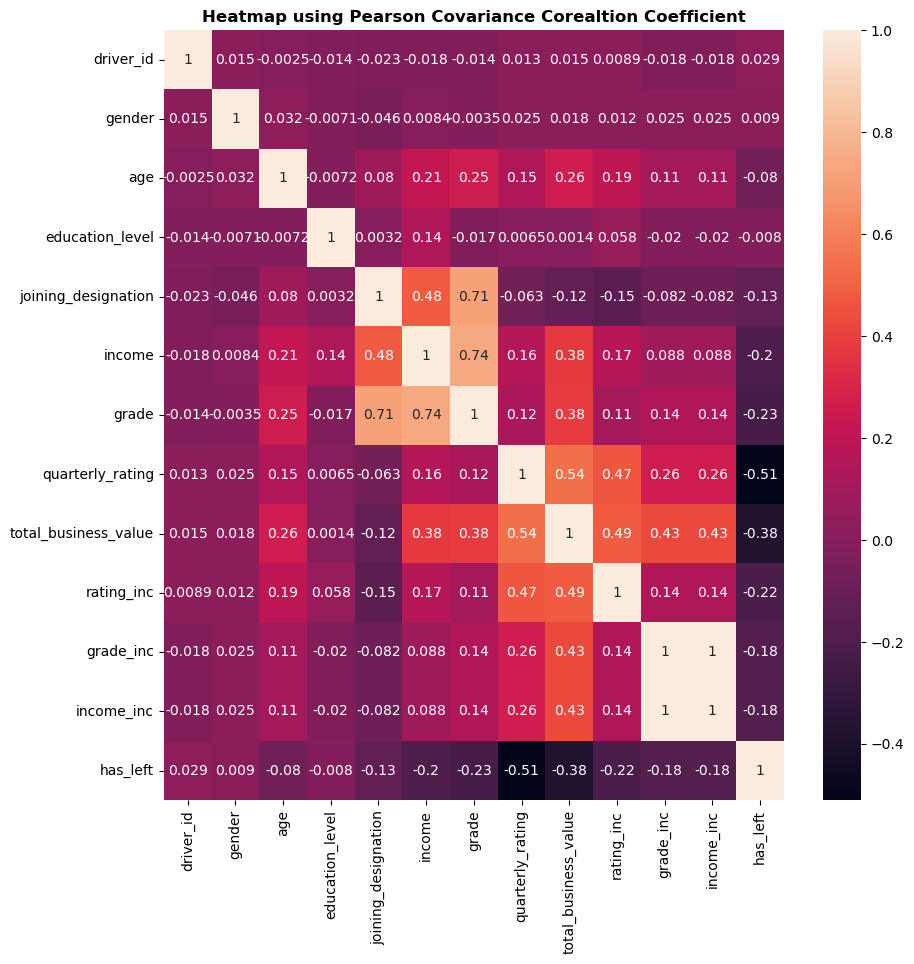

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df_grouped.select_dtypes(include=['number'])

plt.figure(figsize = (10,10))
sns.heatmap(numeric_df.corr(method = 'pearson'),annot=True)
plt.title(f"Heatmap using Pearson Covariance Corealtion Coefficient", fontweight = 'bold')
plt.show()

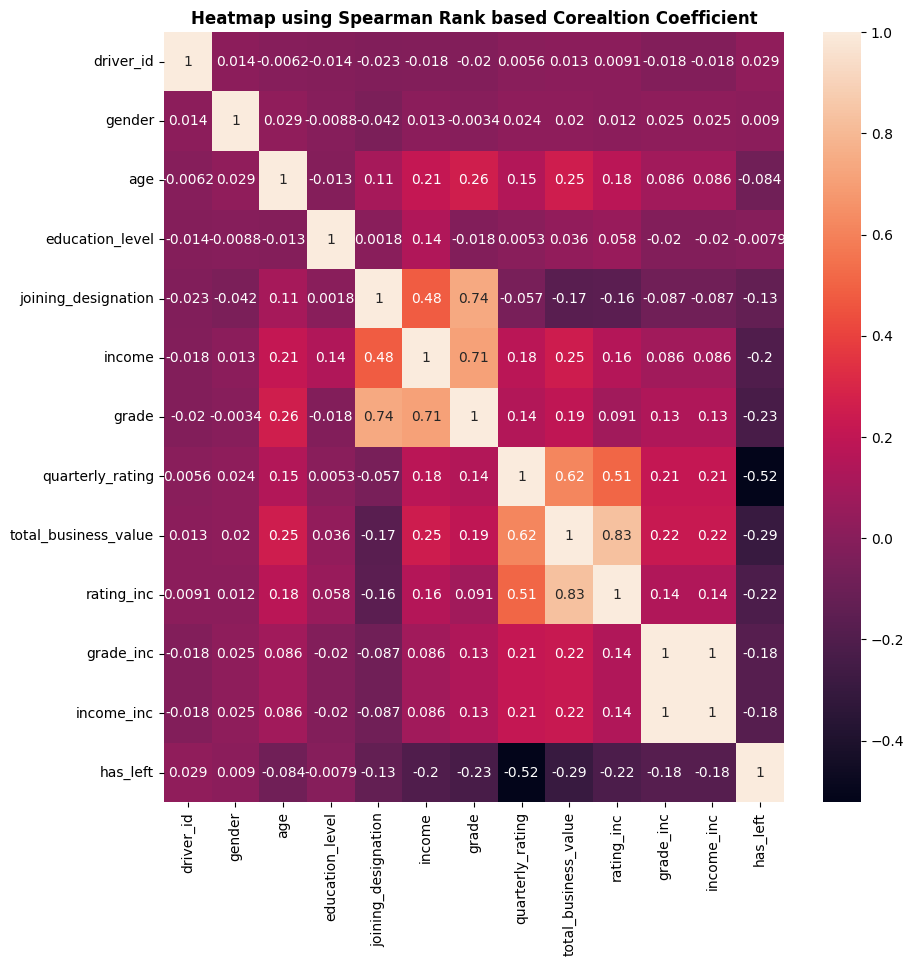

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df_grouped.select_dtypes(include=['number'])

plt.figure(figsize = (10,10))
sns.heatmap(numeric_df.corr(method = 'spearman'),annot=True)
plt.title(f"Heatmap using Spearman Rank based Corealtion Coefficient", fontweight = 'bold')
plt.show()

In [ ]:
def kde_boxplot(data, x, font_size, target=None):
  plt.figure(figsize = (20,7))
  plt.subplot(1,2,1)
  sns.kdeplot(data = data, x = x, hue = target)
  if target != None:
    plt.title(label = "Distribution of "+x+" for different "+target,
    y = -0.2,
    fontsize = font_size,
    fontweight = 'bold')
  else:
    plt.title(label = "Distribution of {x}",
    y = -0.2,
    fontsize = font_size,
    fontweight = 'bold')
  plt.grid()

  plt.subplot(1,2,2)
  sns.boxplot(data=data, x = target, y = x)
  if target != None:
    plt.title(label = "Boxplot showing distribution of "+x+" for different "+target,
    y = -0.2,
    fontsize = font_size,
    fontweight = 'bold')
  if data[target].nunique() > 5:
    plt.xticks(rotation = 75)
  else:
    plt.title(label = "Boxplot showing distribution of "+x,
    y = -0.2,
    fontsize = font_size,
    fontweight = 'bold')
  plt.grid(which='both')
  plt.show()

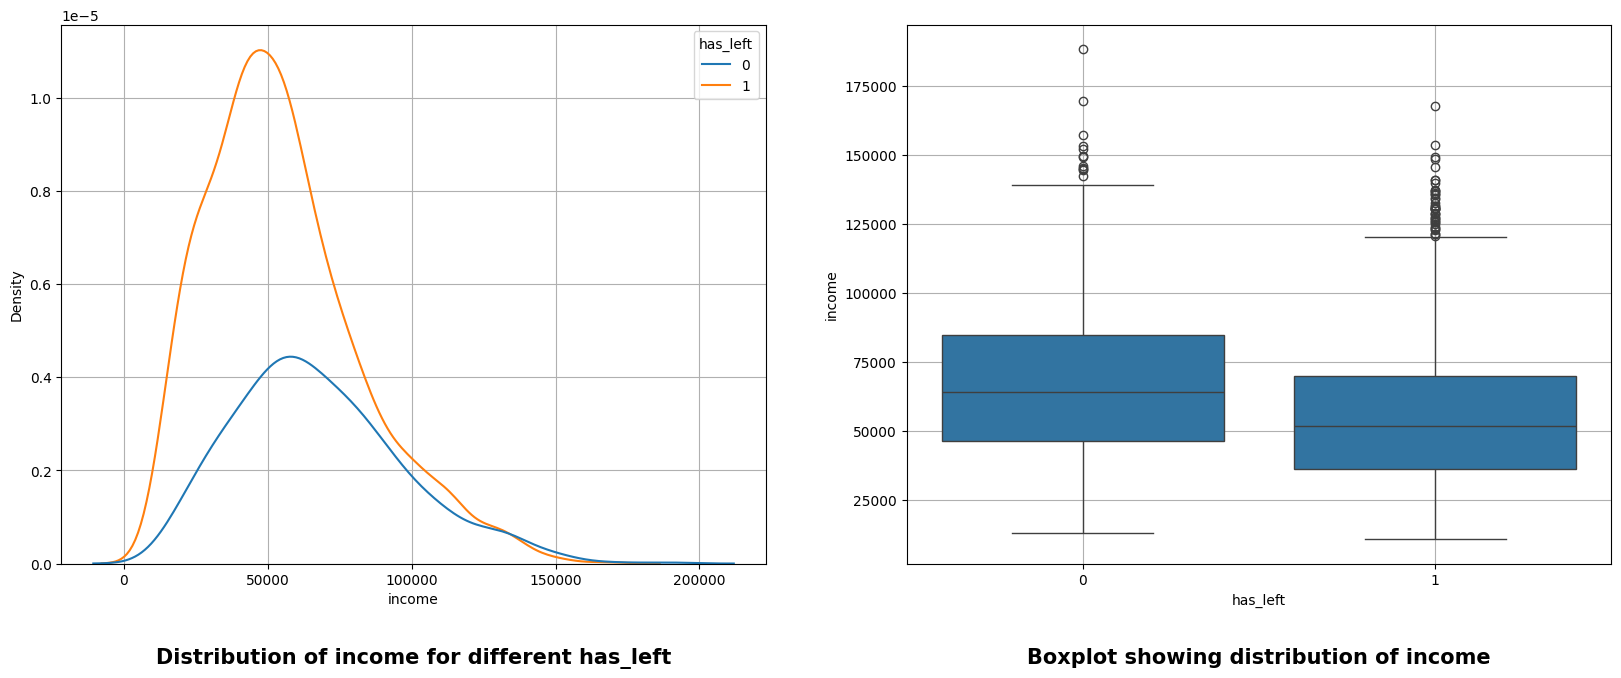

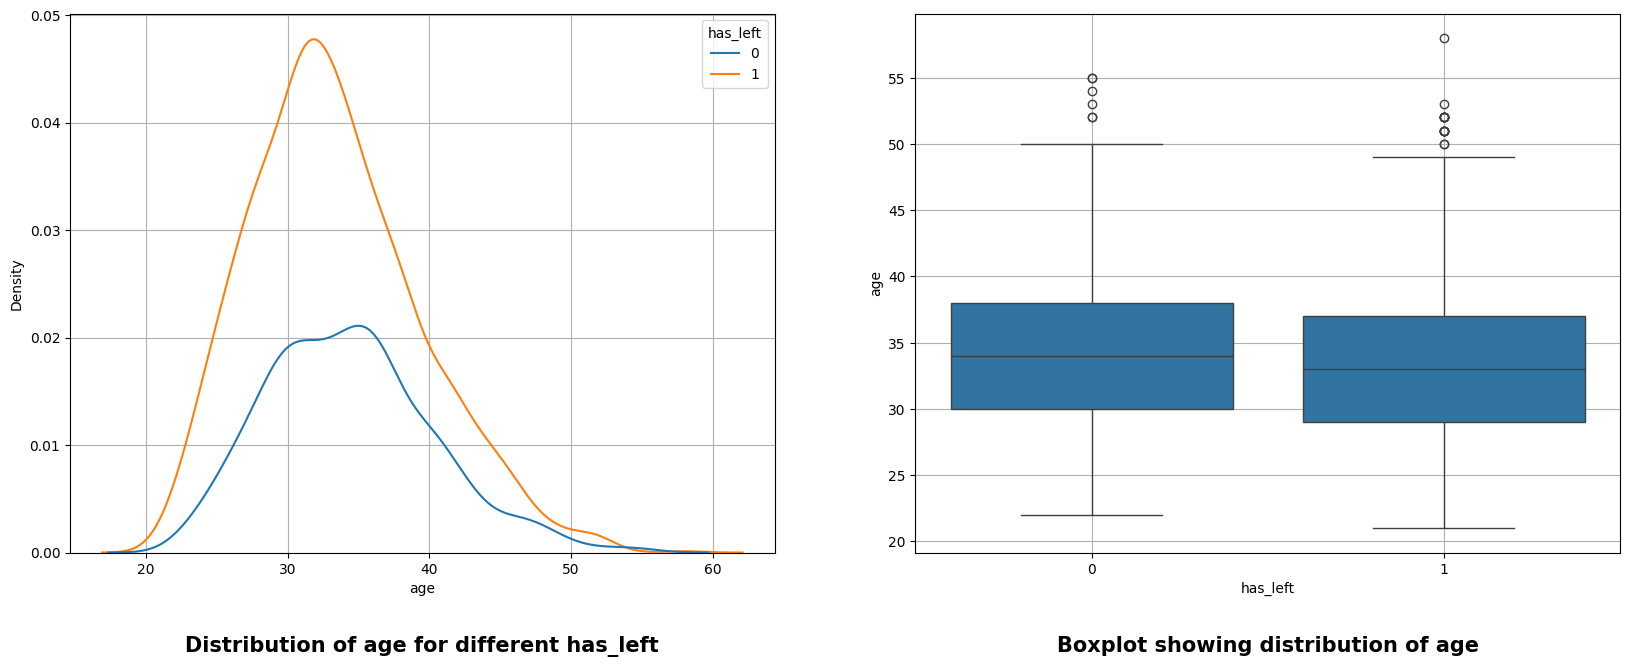

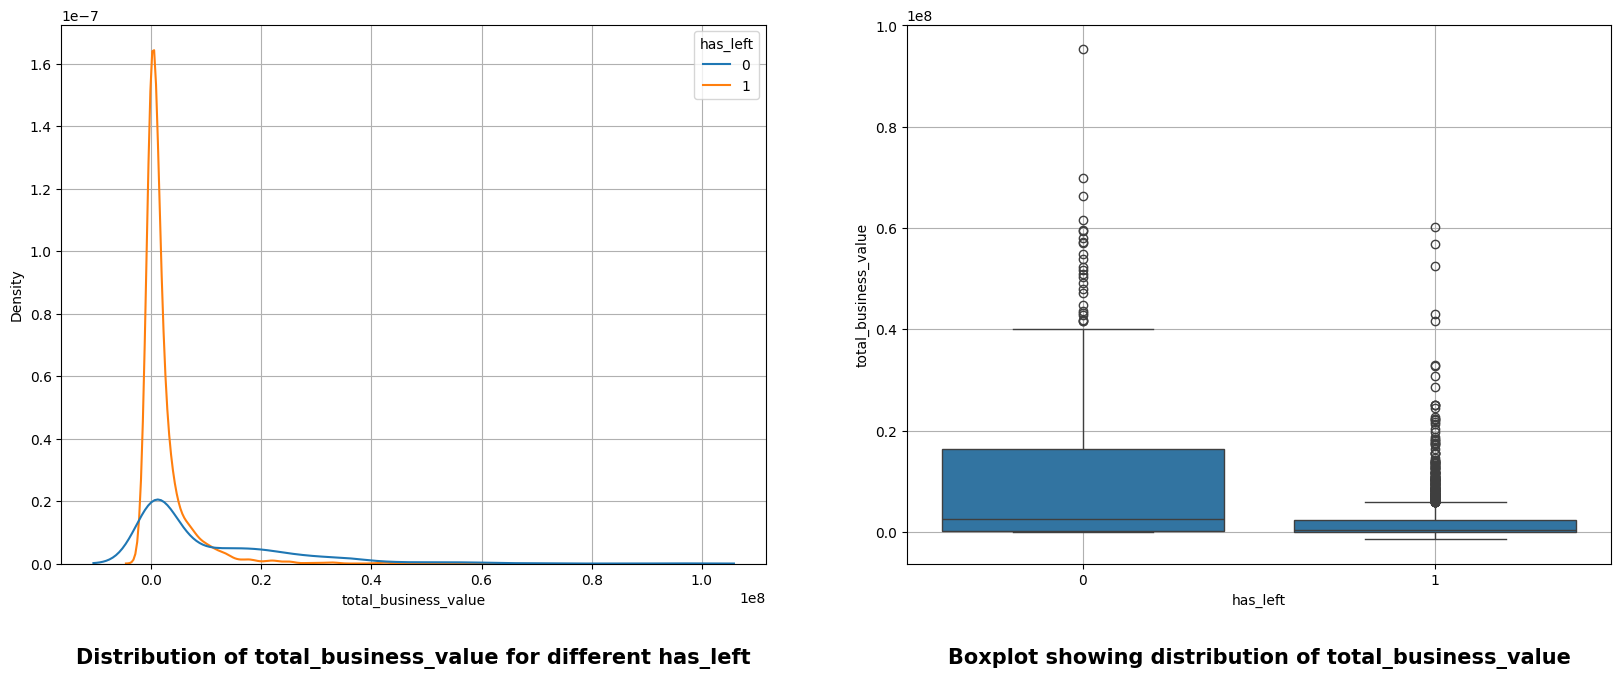

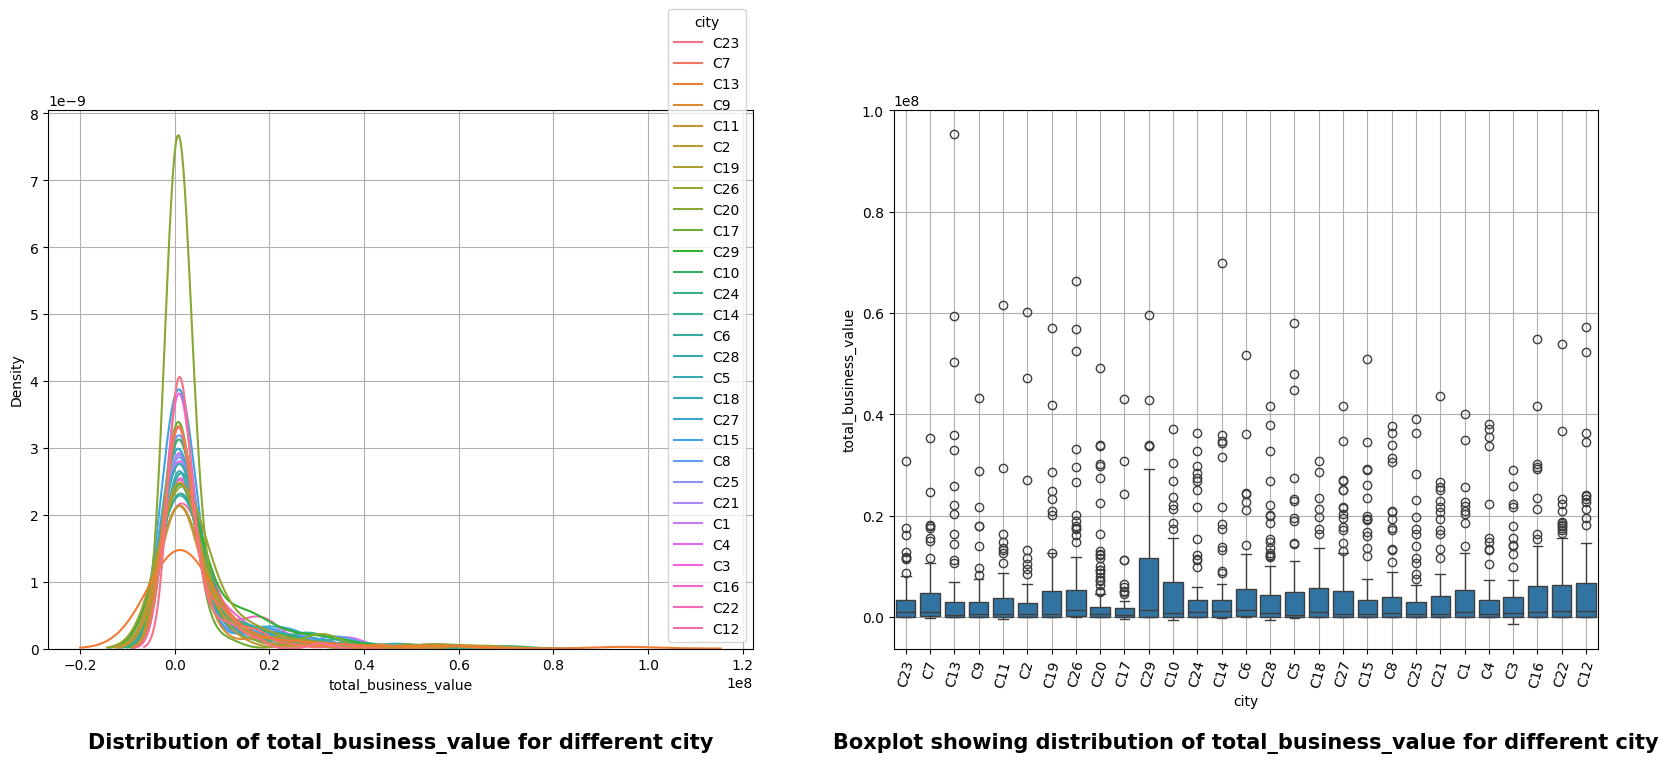

In [ ]:
kde_boxplot(df_grouped, 'income', target = 'has_left', font_size = 15)
kde_boxplot(df_grouped, 'age', target = 'has_left', font_size = 15)
kde_boxplot(df_grouped, 'total_business_value', target = 'has_left', font_size = 15)
kde_boxplot(df_grouped, 'total_business_value', target = 'city', font_size = 15)

In [114]:
def freq_plot(data, x, target = 'has_left'):
  if len(data[x].value_counts()) > 10:
    plt.figure(figsize = (15,10))
    sns.countplot(data=data, x= x, hue = target, order = df_grouped[x].value_counts().index)
    plt.xticks(rotation = 45)
  else:
    sns.countplot(data=data, x= x, hue = target)
    plt.title(f"Frequency count of churn {x} wise", fontweight = 'bold')
    plt.show()

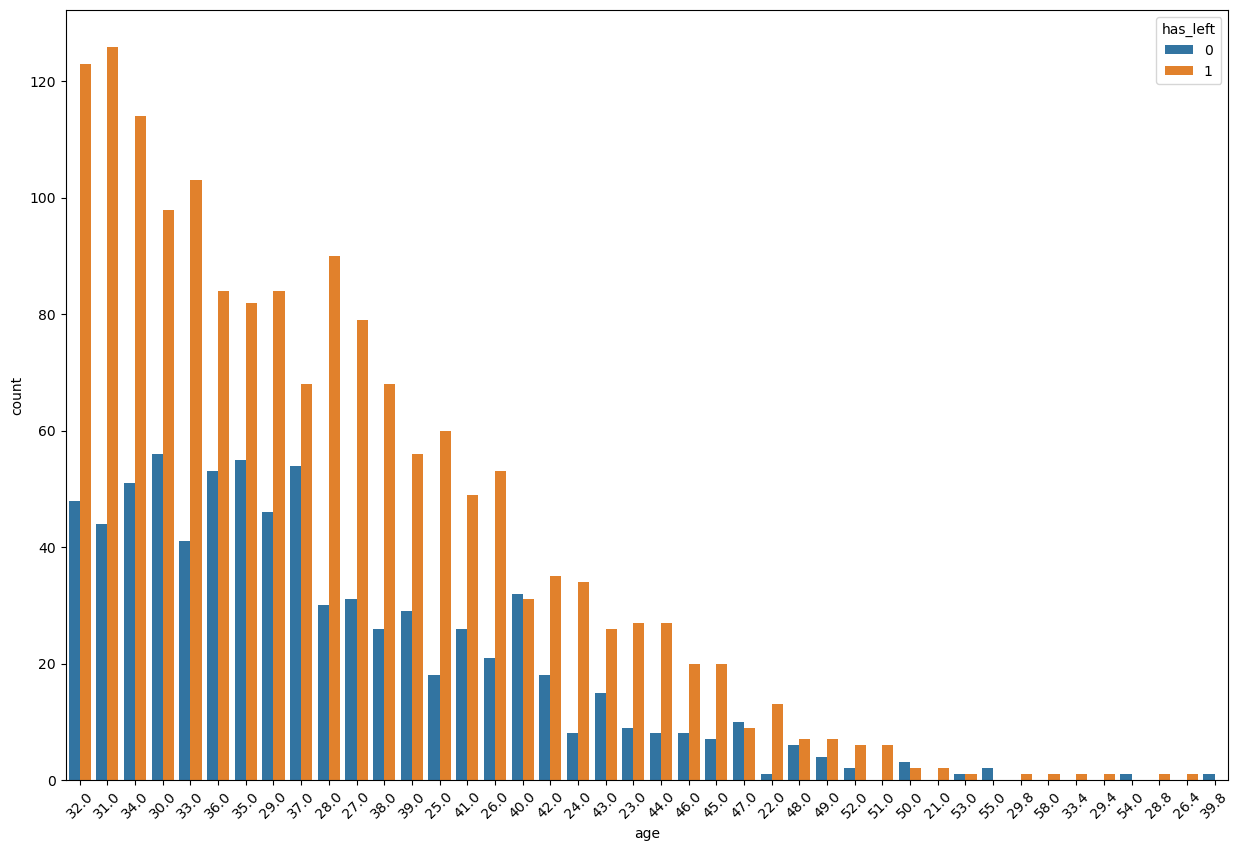

In [115]:
freq_plot(df_grouped, 'age')

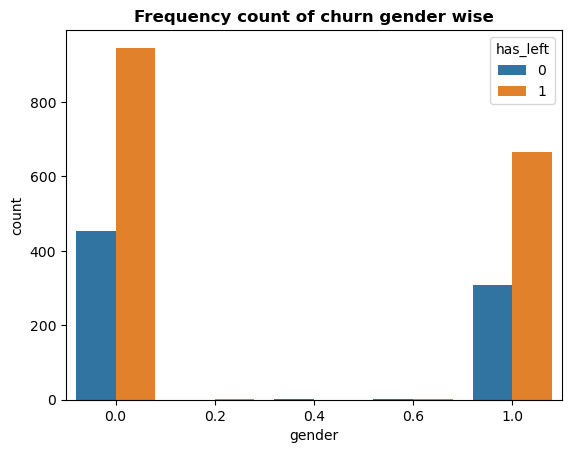

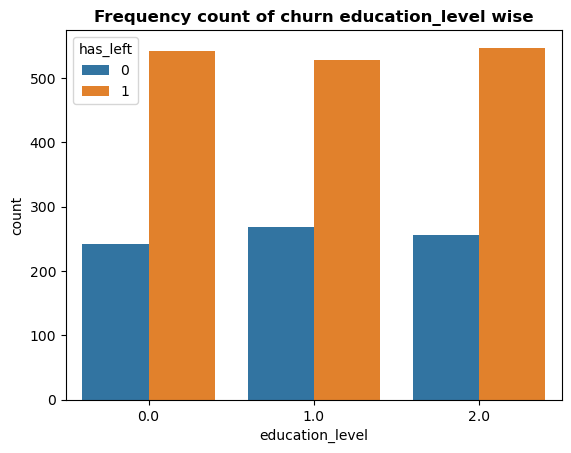

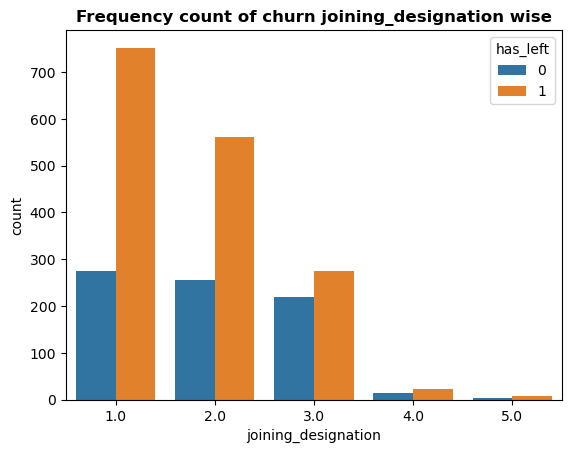

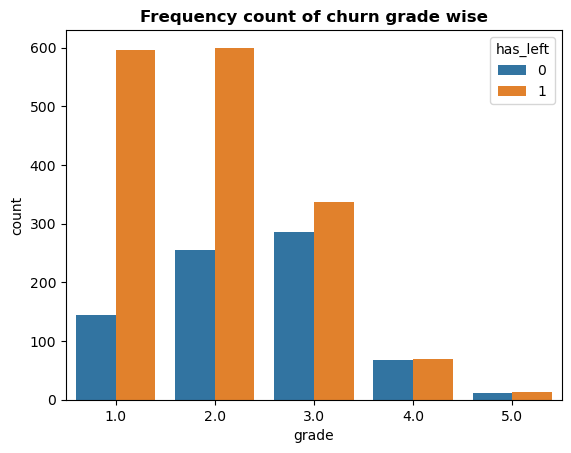

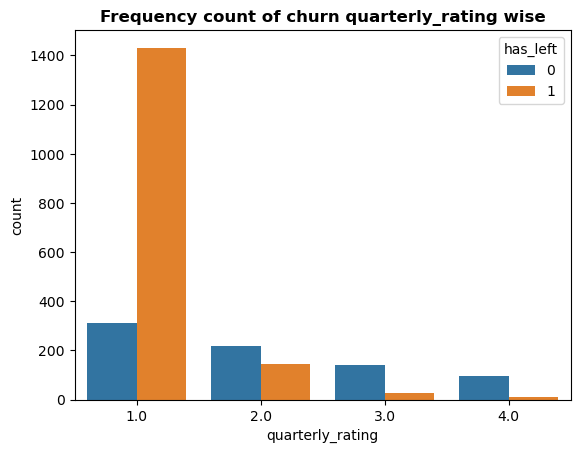

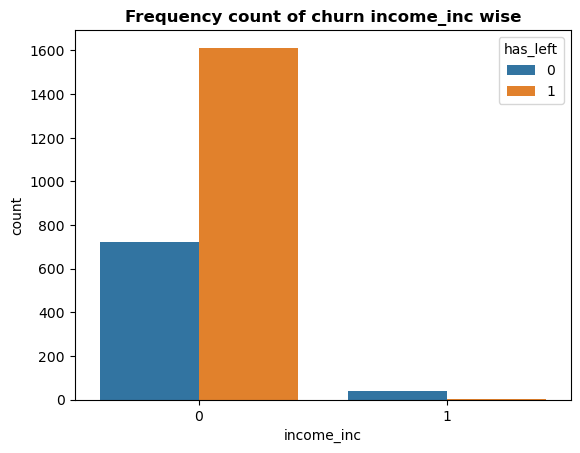

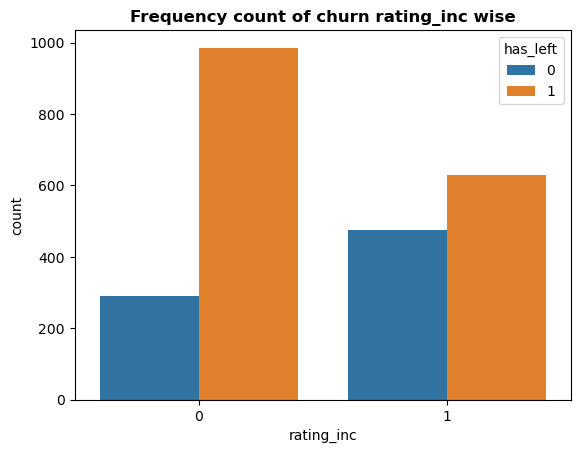

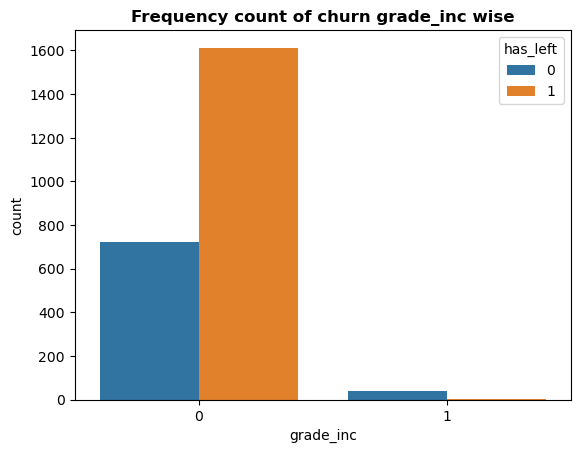

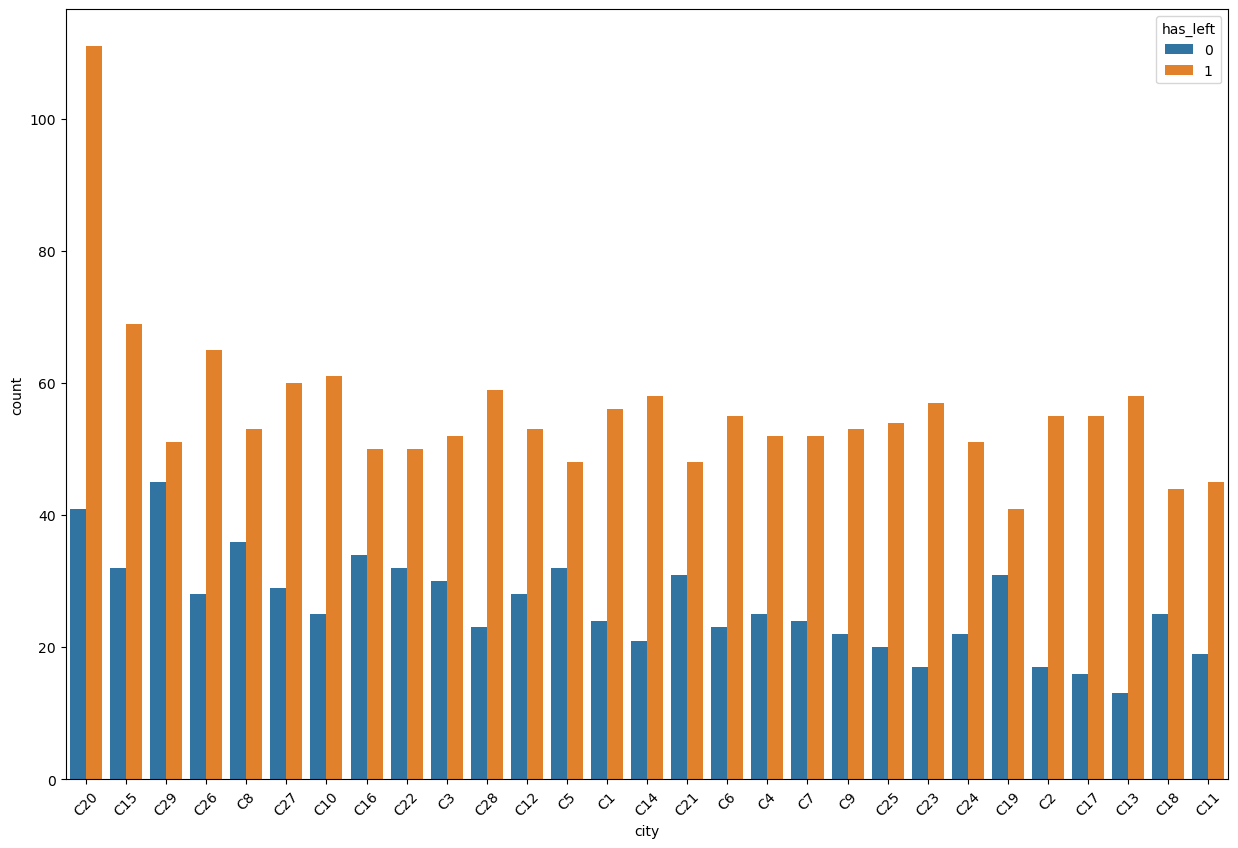

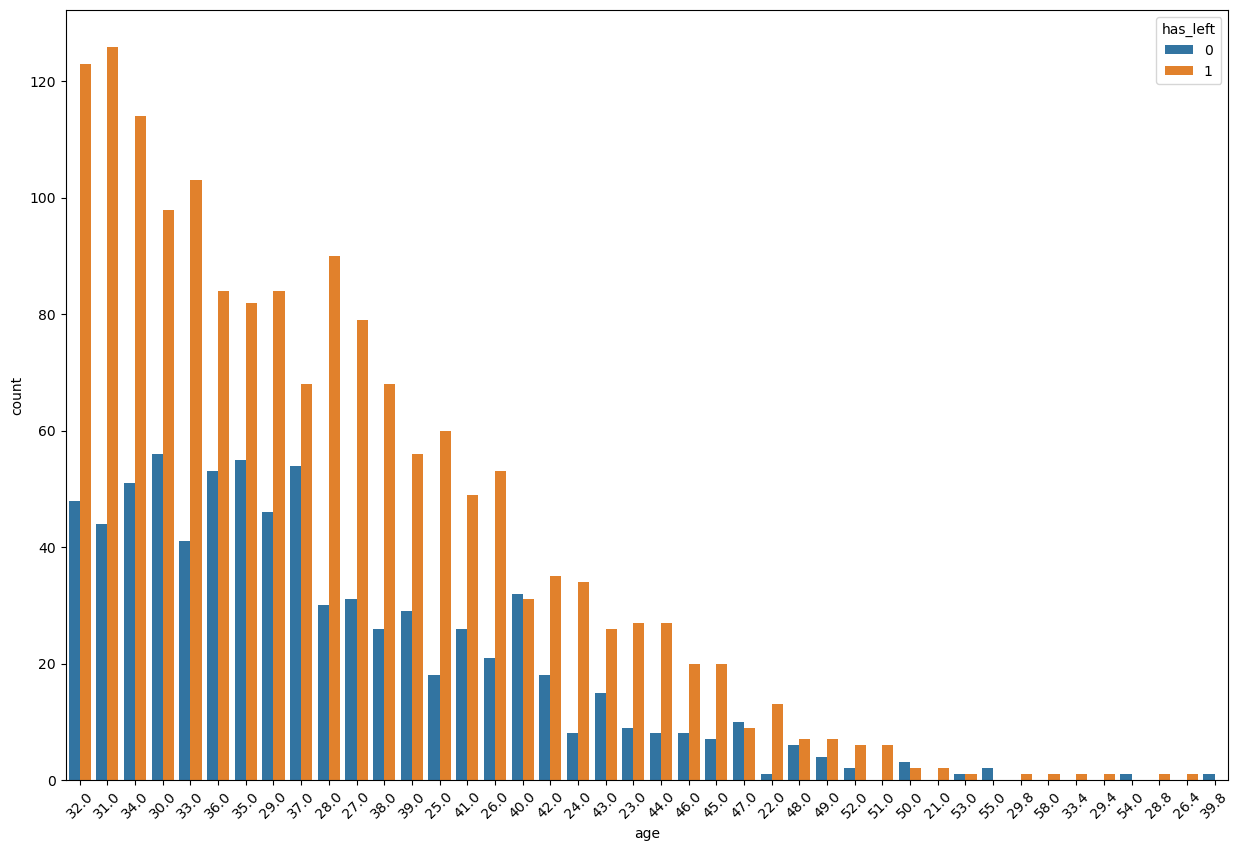

In [116]:
freq_plot(df_grouped, 'gender')
freq_plot(df_grouped, 'education_level')
freq_plot(df_grouped, 'joining_designation')
freq_plot(df_grouped, 'grade')
freq_plot(df_grouped, 'quarterly_rating')
freq_plot(df_grouped, 'income_inc')
freq_plot(df_grouped, 'rating_inc')
freq_plot(df_grouped, 'grade_inc')
freq_plot(df_grouped, 'city')
freq_plot(df_grouped, 'age')

Data Preprocessing (50 Points)
- KNN Imputation
- Feature Engineering
- Class Imbalance treatment
- Standardization
- Encoding

In [168]:
df_grouped

,driver_id,gender,age,education_level,city,joining_designation,date,dateofjoining,lastworkingdate,income,grade,quarterly_rating,total_business_value,rating_inc,grade_inc,income_inc,has_left
0,1.0,0.0,28.0,2.0,C23,1.0,2019-03-01,2018-12-24,03/11/19,57387.0,1.0,2.0,1715580.0,0,0,0,1
1,2.0,0.0,31.0,2.0,C7,2.0,2020-12-01,2020-11-06,<NA>,67016.0,2.0,1.0,0.0,0,0,0,0
2,4.0,0.0,43.0,2.0,C13,2.0,2020-04-01,2019-12-07,27/04/20,65603.0,2.0,1.0,350000.0,0,0,0,1
3,5.0,0.0,29.0,0.0,C9,1.0,2019-03-01,2019-01-09,03/07/19,46368.0,1.0,1.0,120360.0,0,0,0,1
4,6.0,1.0,31.0,1.0,C11,3.0,2020-12-01,2020-07-31,<NA>,78728.0,3.0,2.0,1265000.0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2376,2784.0,0.0,34.0,0.0,C24,2.0,2020-12-01,2015-10-15,<NA>,82815.0,3.0,4.0,21748820.0,1,0,0,0
2377,2785.0,1.0,34.0,0.0,C9,1.0,2020-10-01,2020-08-28,28/10/20,12105.0,1.0,1.0,0.0,0,0,0,1
2378,2786.0,0.0,45.0,0.0,C19,2.0,2019-09-01,2018-07-31,22/09/19,35370.0,2.0,1.0,2815090.0,1,0,0,1
2379,2787.0,1.0,28.0,2.0,C20,1.0,2019-06-01,2018-07-21,20/06/19,69498.0,1.0,1.0,977830.0,1,0,0,1


In [169]:
df_grouped.isna().sum()

driver_id                 0
gender                    0
age                       0
education_level           0
city                      0
joining_designation       0
date                      0
dateofjoining             0
lastworkingdate         765
income                    0
grade                     0
quarterly_rating          0
total_business_value      0
rating_inc                0
grade_inc                 0
income_inc                0
has_left                  0
dtype: int64

### Data Spliting

In [171]:
X = df_grouped.drop(['has_left','lastworkingdate','date', 'driver_id', 'dateofjoining' ], axis = 1)
y = df_grouped['has_left']

In [172]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.25,
                                                    random_state=43,
                                                    shuffle = True)

### Category Encoding

In [ ]:
# pip install category_encoders

In [173]:
from category_encoders import TargetEncoder
te_columns = ['city']
te = TargetEncoder()
X_train[te_columns] = te.fit_transform(X = X_train[te_columns], y = y_train)
X_test[te_columns] = te.transform(X_test[te_columns])

### Features Scaling

In [174]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Model Training DT, RF, XGB

In [175]:
from sklearn.tree import DecisionTreeClassifier

DT = DecisionTreeClassifier(criterion='entropy')
DT.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy')

In [176]:
DT.score(X_test, y_test)

0.7332214765100671

In [178]:
# import matplotlib.pyplot as plt
# from sklearn.tree import plot_tree
# plt.figure(figsize=(14,14))
# plot_tree(model, filled = True)


In [177]:
from IPython.display import Image
from six import StringIO
from sklearn.tree import export_graphviz
import pydot
features = ['gender', 'age', 'education_level', 'city', 'joining_designation',
       'income', 'grade', 'quarterly_rating', 'total_business_value',
       'rating_inc', 'grade_inc', 'income_inc']
dot_data = StringIO()
export_graphviz(DT, out_file=dot_data, feature_names=features, filled=True)
graph = pydot.graph_from_dot_data(dot_data.getvalue())
Image(graph[0].create_png())


ModuleNotFoundError: No module named 'pydot'

### Hyper Parameter Tunning

In [179]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [183]:
# 1. Bagging - Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import numpy as np

# Parameter grid
param_grid = {
 'n_estimators' : [50, 100, 150, 200],
 'max_depth' : list(range(3,30,3)),
 'min_samples_split' : list(range(2,40,2)),
 'min_samples_leaf' : np.linspace(0,0.1,20),
 'class_weight' : ['balanced', None],
 'oob_score' : [False, True]
}

# Simplified parameter grid for fast comulation
# Reduced combinations: From potentially >10,000 to just 36
# param_grid = {
#     'n_estimators': [100, 150],
#     'max_depth': [5, 10, 15],
#     'min_samples_split': [2, 10],   
#     'min_samples_leaf': [1, 5],    
#     'class_weight': ['balanced'],
#     'oob_score': [True]
# }

# Instantiate RFC
rfc = RandomForestClassifier(n_jobs=-1, random_state=42)

# Grid search
gs = GridSearchCV(estimator=rfc, param_grid=param_grid, cv=3, n_jobs=-1, scoring='f1')
gs.fit(X_train, y_train)

# oob_score=True only to reduce computation.
# cv=3 instead of 4 split for faster computation.

GridSearchCV(cv=3, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'class_weight': ['balanced'], 'max_depth': [5, 10, 15],
                         'min_samples_leaf': [1, 5],
                         'min_samples_split': [2, 10],
                         'n_estimators': [100, 150], 'oob_score': [True]},
             scoring='f1')

In [ ]:
# 2. Boosting - XGBoost

# xgb = XGBClassifier(n_jobs = -1)
# param_grid = {
#  'n_estimators' : np.arange(10,200,10),
#  'max_depth' : np.arange(3,30,2),
#  'max_leaves' : [0]
# }
# gs_xgb = GridSearchCV(estimator = xgb, param_grid = param_grid, cv = 4, scoring = 'f1', n_jobs = -1)
# gs_xgb.fit(X_train, y_train)


In [185]:
# Best random forest paramteres are as follow:
gs.best_estimator_

RandomForestClassifier(class_weight='balanced', max_depth=15, n_jobs=-1,
                       oob_score=True, random_state=42)

In [186]:
print("Best hyperparameters:")
for k, v in gs.best_params_.items():
    print(f"{k}: {v}")

Best hyperparameters:
class_weight: balanced
max_depth: 15
min_samples_leaf: 1
min_samples_split: 2
n_estimators: 100
oob_score: True


In [189]:
best_rfc = gs.best_estimator_
y_pred = best_rfc.predict(X_test)

### Evalutation

In [190]:
from sklearn.metrics import confusion_matrix, f1_score, recall_score, precision_score, ConfusionMatrixDisplay

In [191]:
y_pred_train = best_rfc.predict(X_train)
y_pred_test = best_rfc.predict(X_test)
best_rfc_summary = pd.DataFrame(data = best_rfc.feature_importances_.reshape(1,-1) , columns = X.columns)
best_rfc_summary['f1_score_train'] = f1_score(y_train, y_pred_train)
best_rfc_summary['f1_score_test'] = f1_score(y_test, y_pred_test)
best_rfc_summary['recall_score_train'] = recall_score(y_train, y_pred_train)
best_rfc_summary['recall_score_test'] = recall_score(y_test, y_pred_test)
best_rfc_summary['precision_score_train'] = precision_score(y_train, y_pred_train)
best_rfc_summary['precision_score_test'] = precision_score(y_test, y_pred_test)

In [34]:
best_rfc_summary

,gender,age,education_level,city,joining_designation,income,grade,quarterly_rating,total_business_value,rating_inc,grade_inc,income_inc,f1_score_train,f1_score_test,recall_score_train,recall_score_test,precision_score_train,precision_score_test
0,0.012181,0.05431,0.016526,0.074142,0.049265,0.086946,0.045903,0.398926,0.227924,0.02501,0.003237,0.00563,0.883167,0.868639,0.944125,0.919799,0.829603,0.82287


In [199]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_test))
cm = confusion_matrix(y_test, y_pred_test)
print(cm)

              precision    recall  f1-score   support

           0       0.74      0.60      0.66       197
           1       0.82      0.89      0.86       399

    accuracy                           0.80       596
   macro avg       0.78      0.75      0.76       596
weighted avg       0.79      0.80      0.79       596

[[118  79]
 [ 42 357]]


- The Decision Tree method out of all predicted 0 the measure of correctly predicted is 74%, and for 1 it is 82%(Precision).
- The Decision Tree method out of all actual 0 the measure of correctly predicted is 60%, and for 1 it is 89%(Recall).

<Axes: >

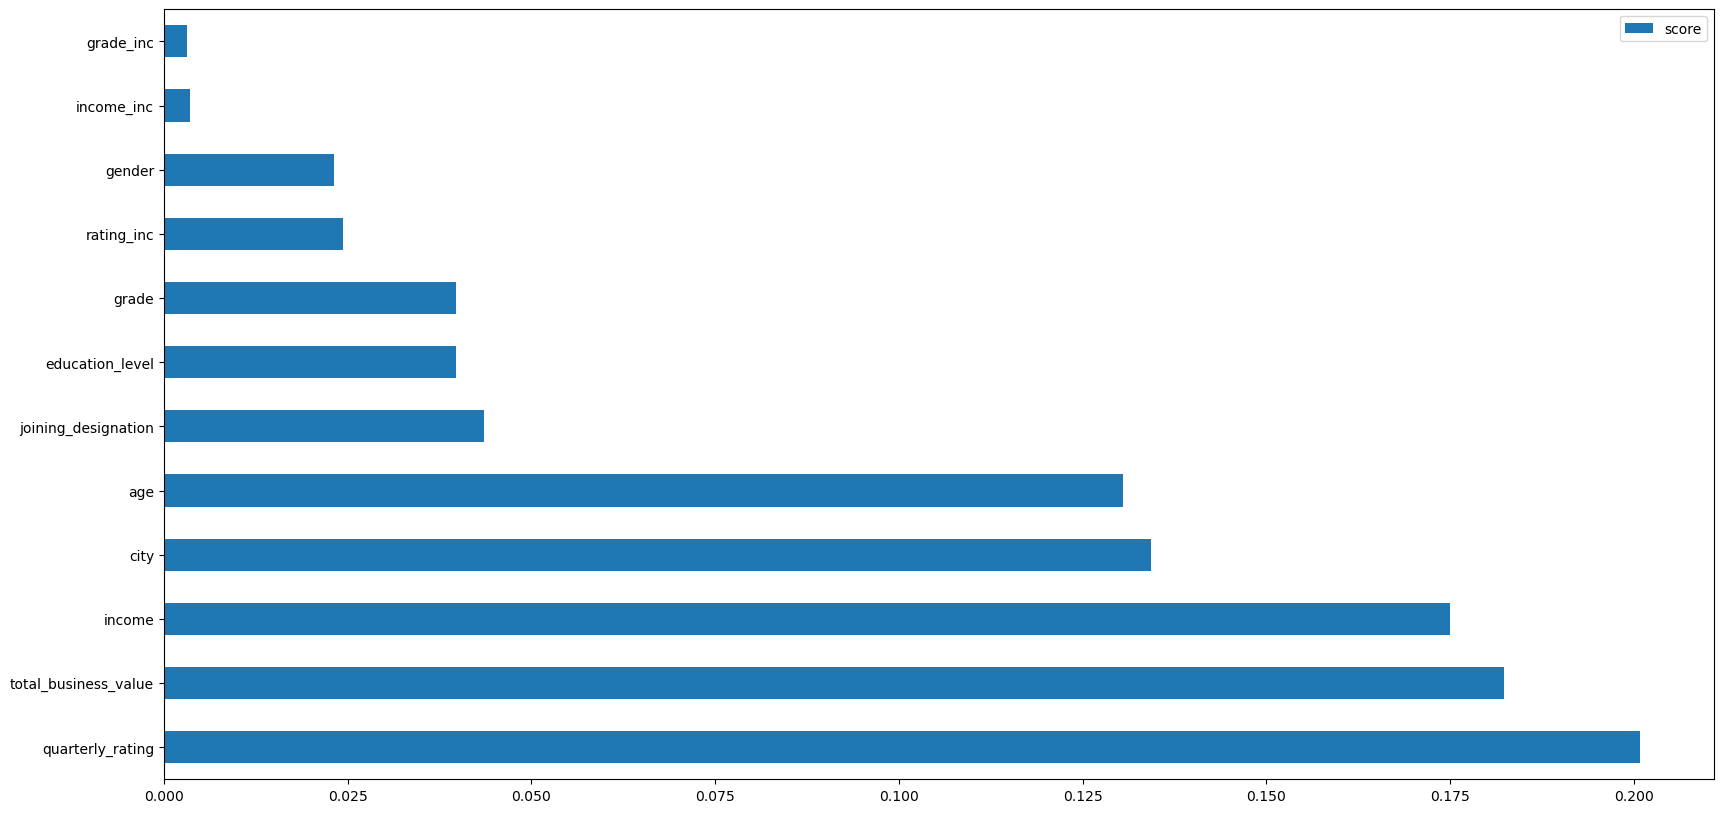

In [194]:
data = pd.DataFrame(data=best_rfc.feature_importances_, index=X.columns, columns=["score"])
data.nlargest(40, columns="score").plot(kind='barh', figsize = (20,10)) ## plot top 40 features

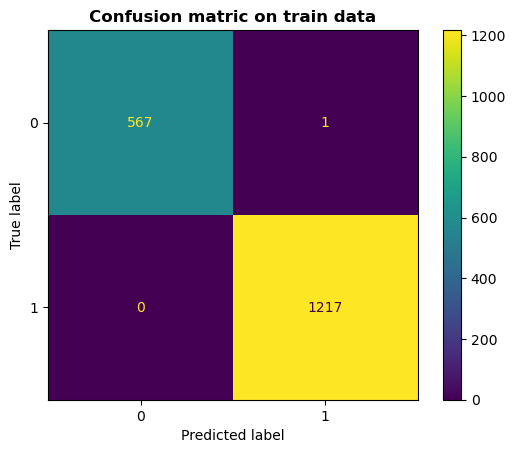

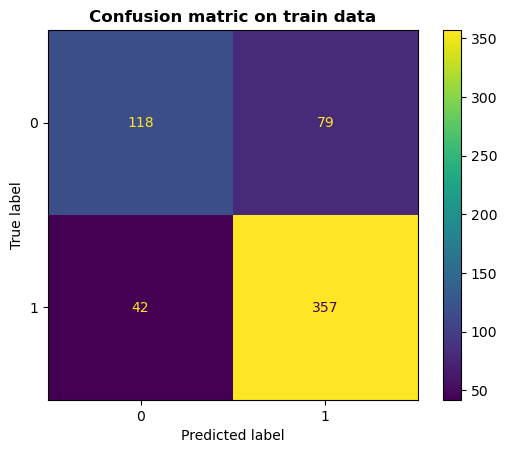

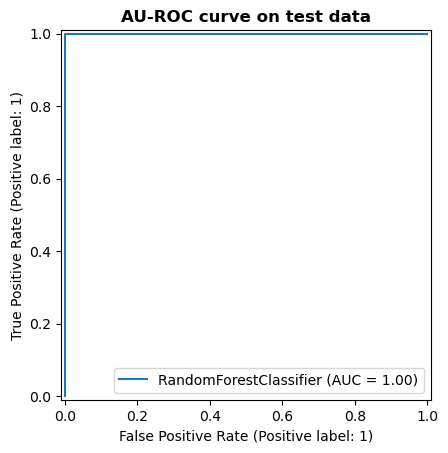

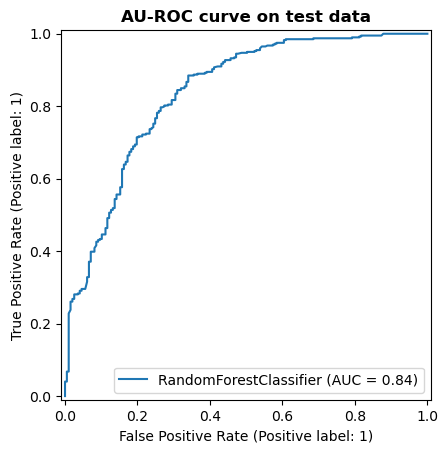

In [193]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay
disp = ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train))
disp.plot()
plt.title('Confusion matric on train data',fontweight = 'bold')
plt.show()
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test))
disp.plot()
plt.title('Confusion matric on train data',fontweight = 'bold')
plt.show()
RocCurveDisplay.from_estimator(best_rfc, X_train, y_train)
plt.title(f"AU-ROC curve on test data", fontweight = 'bold')
plt.show()
RocCurveDisplay.from_estimator(best_rfc, X_test, y_test)
plt.title(f"AU-ROC curve on test data", fontweight = 'bold')
plt.show()

### Insights

- The most important part for this analysis was to find someone will churn or not but at the same time we also don't wan't to
regrade the business, hence f1 score is used as the validation score.
- Both the model created above provides great performance on unseen data, the recall score for random forest is 93% and that
of Extreme gradient boost is 92%.
- The most important parameter turns out to be quarterly rating, higher quarterly rating indicates higher chances of drivers
churning the company.
- City, joining desgination, Grade of the driver are also very important with respect to churning.
- Business value also plays important role to determine churn.
- The AU-ROC for extreme GBC is 0.81 on test data.
- The AU-ROC for extreme GBC is 0.80 on test data.


Actionable Insights & Recommendations:

- Drivers should be trained before starting their journy with the company where they should learn about
Customer Treatment
- Effect of cancellation or refunds on their performance measures.
- Effect of quarterly rating and grade accociated with them.
- Responsive support from the company should be provided, if drivers have quaries or issues they need to be resolved swiftly.
- Customer satisfaction is indeed one of the most important parameter for the business but one should also emphasize on the
- system behind that business that is drivers and their satisfaction as well.
- Some cities are performing better than the rest, we need inferences about that city and need to learn the root causes why they
are performing better than the rest.
- Age group of 27-36 is most dominant in terms of churning, we need to keep an extra eye upon then and survey these dirvers
on how we can improve their experience with OLA and know the reason why are they curning.
- Drivers who has Low quarterly rating, Low grade, have joining designation 1,2 or 3 are very likely to churn, meaning these are relatively new drivers and maybe they are
trying all the choices they have, we need to thrive this opportunity to retain as much drivers as possible.